In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OneHotEncoder,StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
import warnings


warnings.filterwarnings('ignore')

In [3]:
import streamlit as st

In [4]:
df = pd.read_csv("flood_risk_ml_dataset.csv")

In [5]:
df.head()

,State,District,Rainfall_mm,River_Water_Level_m,Reservoir_Level_pct,Soil_Moisture_pct,Temperature_C,Humidity_pct,Elevation_m,Slope_deg,Drainage_Quality,Land_Use,Population_Density,Flood_History,Month,Flood_Risk
0,Assam,Nagaon,12.8,4.73,47.8,81.1,16.5,68.1,117.3,1.04,Poor,Wetland,67,Yes,January,Medium
1,Assam,Dibrugarh,23.8,4.68,43.4,76.9,17.8,63.2,107.4,3.41,Poor,Wetland,606,Yes,January,Medium
2,Assam,Barpeta,30.4,4.94,32.3,58.0,18.8,56.9,46.6,1.38,Moderate,Agricultural,256,Yes,January,Low
3,Assam,Nagaon,56.1,4.81,34.5,45.3,15.6,61.5,56.4,2.18,Poor,Agricultural,752,No,January,Low
4,Assam,Nagaon,25.4,4.72,33.9,71.1,15.7,65.5,109.8,2.47,Moderate,Wetland,518,Yes,January,Medium


In [6]:
df.shape

(5544, 16)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5544 entries, 0 to 5543
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   State                5544 non-null   str    
 1   District             5544 non-null   str    
 2   Rainfall_mm          5544 non-null   float64
 3   River_Water_Level_m  5544 non-null   float64
 4   Reservoir_Level_pct  5544 non-null   float64
 5   Soil_Moisture_pct    5544 non-null   float64
 6   Temperature_C        5544 non-null   float64
 7   Humidity_pct         5544 non-null   float64
 8   Elevation_m          5544 non-null   float64
 9   Slope_deg            5544 non-null   float64
 10  Drainage_Quality     5544 non-null   str    
 11  Land_Use             5544 non-null   str    
 12  Population_Density   5544 non-null   int64  
 13  Flood_History        5544 non-null   str    
 14  Month                5544 non-null   str    
 15  Flood_Risk           5544 non-null   str    
dtyp

In [8]:
df.describe()

,Rainfall_mm,River_Water_Level_m,Reservoir_Level_pct,Soil_Moisture_pct,Temperature_C,Humidity_pct,Elevation_m,Slope_deg,Population_Density
count,5544.000000,5544.000000,5544.000000,5544.000000,5544.000000,5544.000000,5544.000000,5544.000000,5544.000000
mean,91.253247,3.770503,55.123196,56.684596,22.496374,69.398052,544.075144,7.251156,3022.471501
std,97.825216,1.708576,17.199196,17.277990,7.378303,15.620544,797.169892,11.149280,4580.042848
min,-0.000000,0.440000,15.000000,16.500000,-5.300000,36.100000,5.100000,0.100000,10.000000
25%,24.475000,2.490000,42.800000,45.300000,17.900000,56.700000,66.075000,1.380000,347.000000
50%,47.000000,3.460000,52.100000,56.000000,23.900000,64.200000,228.050000,2.600000,710.000000
75%,141.325000,4.940000,65.700000,67.700000,27.700000,84.400000,531.775000,4.900000,4921.000000
max,552.500000,9.460000,100.000000,98.000000,38.100000,100.000000,3595.200000,67.390000,32342.000000


In [9]:
df.isnull().sum()

State                  0
District               0
Rainfall_mm            0
River_Water_Level_m    0
Reservoir_Level_pct    0
Soil_Moisture_pct      0
Temperature_C          0
Humidity_pct           0
Elevation_m            0
Slope_deg              0
Drainage_Quality       0
Land_Use               0
Population_Density     0
Flood_History          0
Month                  0
Flood_Risk             0
dtype: int64

In [10]:
df.duplicated().sum()


np.int64(0)

In [11]:
df["Flood_Risk"].value_counts()

Flood_Risk
Low        2855
Medium     1673
High        681
Extreme     335
Name: count, dtype: int64

In [12]:
df["Flood_Risk"].value_counts(normalize=True) * 100

Flood_Risk
Low        51.497114
Medium     30.176768
High       12.283550
Extreme     6.042569
Name: proportion, dtype: float64

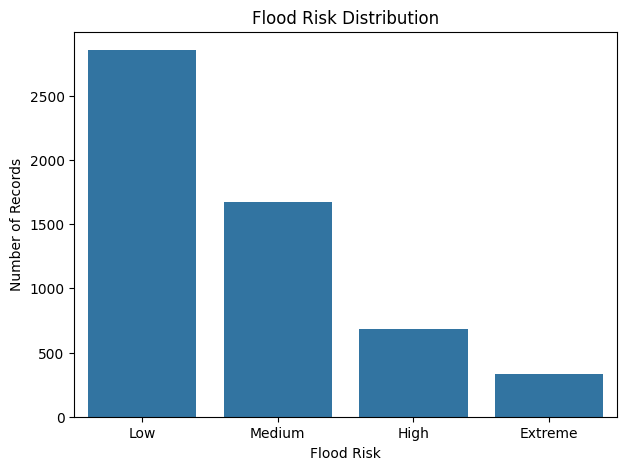

In [13]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Flood_Risk",
    order=["Low", "Medium", "High", "Extreme"]
)

plt.title("Flood Risk Distribution")
plt.xlabel("Flood Risk")
plt.ylabel("Number of Records")
plt.show()

numerical features

In [14]:
df["Rainfall_mm"].describe()

count    5544.000000
mean       91.253247
std        97.825216
min        -0.000000
25%        24.475000
50%        47.000000
75%       141.325000
max       552.500000
Name: Rainfall_mm, dtype: float64

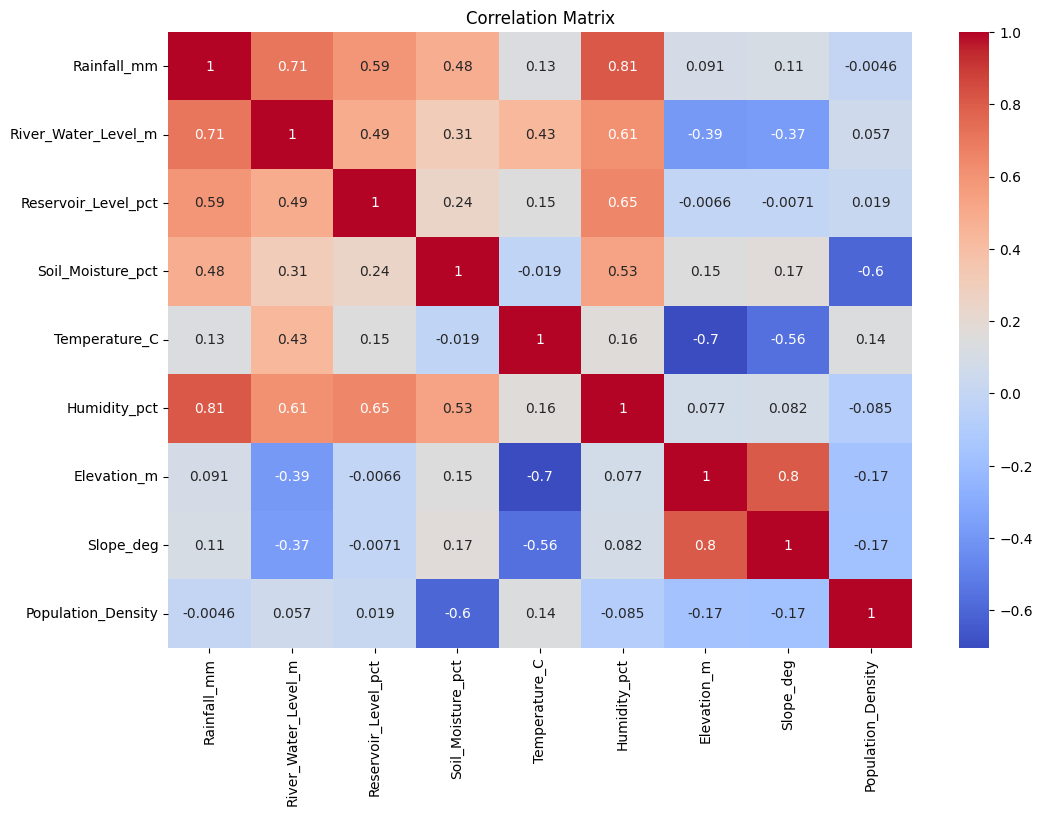

In [16]:
numeric_df = df.select_dtypes(include="number")

plt.figure(figsize=(12,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

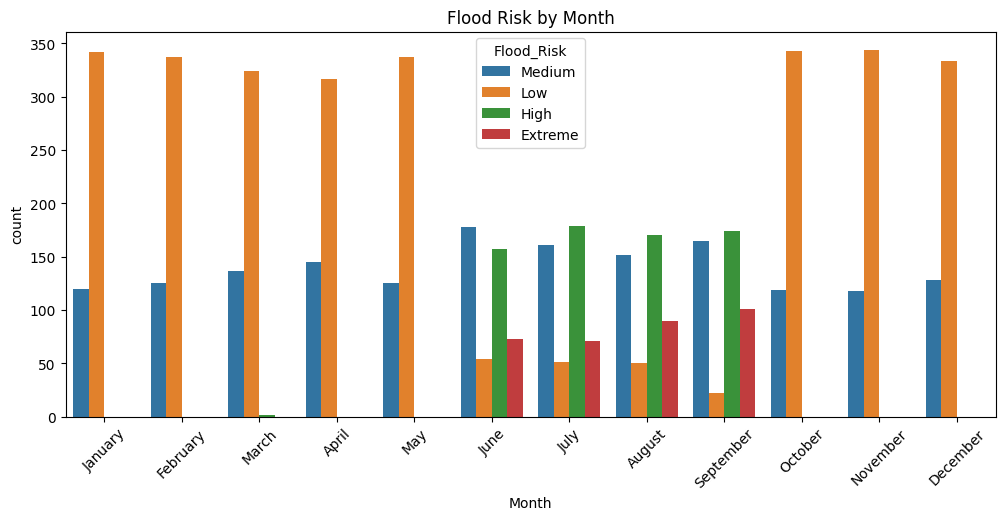

In [17]:
month_order = [
    "January", "February", "March", "April",
    "May", "June", "July", "August",
    "September", "October", "November", "December"
]

plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Month",
    hue="Flood_Risk",
    order=month_order,
)

plt.xticks(rotation=45)
plt.title("Flood Risk by Month")
plt.show()

In [18]:
x=df.drop(["Flood_Risk","Population_Density"],axis=1)
y=df["Flood_Risk"]

In [19]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.20,random_state=42,stratify=y)

In [20]:
cat_col=x.select_dtypes(include="object").columns
num_col=x.select_dtypes(include=np.number).columns

In [21]:
cat_col
num_col

Index(['Rainfall_mm', 'River_Water_Level_m', 'Reservoir_Level_pct',
       'Soil_Moisture_pct', 'Temperature_C', 'Humidity_pct', 'Elevation_m',
       'Slope_deg'],
      dtype='str')

In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical",OneHotEncoder(handle_unknown="ignore"),cat_col),
         ("numerical",StandardScaler(),num_col)
    ]
)

In [23]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``

In [24]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression())
])

In [25]:
model.fit(xtrain,ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['Extreme','High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['State','District','Rainfall_mm',...,'Land_Use','Flood_History','Month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [26]:
y_pred=model.predict(xtest)

In [28]:
accuracy_score(ytest,y_pred)*100

91.43372407574391

In [29]:
confusion_matrix(ytest,y_pred)

array([[ 58,   9,   0,   0],
       [  2, 124,   0,  10],
       [  0,   0, 542,  29],
       [  0,  15,  30, 290]])

In [30]:
f1_score(ytest,y_pred,average="macro")

0.9021251729033617

Random Forest

In [31]:
rf=RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    # class_weight="balanced"
)

In [32]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", rf)
])

In [33]:
rf_model.fit(xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](4,)","['Extreme','High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['State','District','Rainfall_mm',...,'Land_Use','Flood_History','Month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'`

In [34]:
rf_pred = rf_model.predict(xtest)

In [69]:
accuracy_score(ytest,rf_pred)*100

84.40036068530208

XG Boost

In [37]:
from xgboost import XGBClassifier

In [38]:
le=LabelEncoder()

ytrain_encoded=le.fit_transform(ytrain)
ytest_encoded=le.transform(ytest)

In [ ]:
xgb=XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0,
    reg_lambda=1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42,
)

In [40]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", xgb)
])

In [41]:
model.fit(xtrain,ytrain_encoded)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](4,)","[0,1,2,3]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['State','District','Rainfall_mm',...,'Land_Use','Flood_History','Month']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numerical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remain

In [42]:
xgb_pred1=model.predict(xtest)

In [43]:
accuracy_score(ytest_encoded,xgb_pred1)

0.9413886384129847

In [44]:
xgb_pred_encoded=model.predict(xtest)

In [45]:
xgb_pred=le.inverse_transform(xgb_pred_encoded.astype(int))

In [46]:
accuracy_score(ytest, xgb_pred)

0.9413886384129847

Support Vector Machine

In [48]:
from sklearn.svm import SVC

In [49]:
svm_model=SVC(kernel="rbf",C=1,gamma="scale",)

In [50]:
xtrain_processed=preprocessor.fit_transform(xtrain)
xtest_processed=preprocessor.transform(xtest)

In [51]:
print(type(xtrain_processed))
print(xtrain_processed.shape)

<class 'scipy.sparse._csr.csr_matrix'>
(4435, 121)


In [52]:
svm_model.fit(
    xtrain_processed,
    ytrain_encoded
)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [53]:
svm_pred1=svm_model.predict(xtest_processed)

In [54]:
accuracy_score(svm_pred1,ytest_encoded)

0.9071235347159603

KNN Model

In [55]:
knn=KNeighborsClassifier(n_neighbors=5,weights="distance",metric="minkowski")

In [56]:
knn.fit(xtrain_processed,ytrain_encoded)

,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'distance'
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](4,)","[0,1,2,3]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [57]:
knn_pred1=knn.predict(xtest_processed)

In [58]:
accuracy_score(knn_pred1,ytest_encoded)

0.8205590622182146

CROSS VALIDATION

In [59]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scores = cross_val_score(
    xgb,
    xtrain_processed,
    ytrain_encoded,
    cv=cv,
    scoring="accuracy"
)

print("CV Scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

CV Scores: [0.93010147 0.93686584 0.94250282 0.95039459 0.95264938]
Mean Accuracy: 0.9425028184892896
Standard Deviation: 0.008376178408571232


In [60]:
feature_names=model.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))
print(feature_names)

121
['categorical__State_Andhra Pradesh' 'categorical__State_Assam'
 'categorical__State_Bihar' 'categorical__State_Delhi'
 'categorical__State_Gujarat' 'categorical__State_Haryana'
 'categorical__State_Himachal Pradesh'
 'categorical__State_Jammu and Kashmir' 'categorical__State_Karnataka'
 'categorical__State_Kerala' 'categorical__State_Madhya Pradesh'
 'categorical__State_Maharashtra' 'categorical__State_Odisha'
 'categorical__State_Punjab' 'categorical__State_Rajasthan'
 'categorical__State_Sikkim' 'categorical__State_Tamil Nadu'
 'categorical__State_Telangana' 'categorical__State_Uttar Pradesh'
 'categorical__State_Uttarakhand' 'categorical__State_West Bengal'
 'categorical__District_Alappuzha' 'categorical__District_Alwar'
 'categorical__District_Ambala' 'categorical__District_Amritsar'
 'categorical__District_Anantnag' 'categorical__District_Bahraich'
 'categorical__District_Balasore' 'categorical__District_Ballia'
 'categorical__District_Baramulla' 'categorical__District_Barpet

In [61]:
importance=model.named_steps["classifier"].feature_importances_

In [62]:
feature_importance=pd.DataFrame({"Feature": feature_names,"Importance": importance})

feature_importance=feature_importance.sort_values(by="Importance",ascending=False)
print(feature_importance.head(20))

                                Feature  Importance
113              numerical__Rainfall_mm    0.107379
98        categorical__Land_Use_Wetland    0.076635
99        categorical__Flood_History_No    0.061634
100      categorical__Flood_History_Yes    0.047455
118             numerical__Humidity_pct    0.047185
94   categorical__Drainage_Quality_Poor    0.034393
116        numerical__Soil_Moisture_pct    0.024039
114      numerical__River_Water_Level_m    0.021161
97          categorical__Land_Use_Urban    0.018375
85          categorical__District_Surat    0.018079
92   categorical__Drainage_Quality_Good    0.017732
120                numerical__Slope_deg    0.017568
115      numerical__Reservoir_Level_pct    0.014567
72         categorical__District_Mumbai    0.013369
96         categorical__Land_Use_Forest    0.010933
48         categorical__District_Ganjam    0.010857
56         categorical__District_Idukki    0.009902
8          categorical__State_Karnataka    0.009695
107         

In [68]:
print("Accuracy score of logistic regression")
print(accuracy_score(ytest,y_pred)*100)
print("\nAccuracy score of random forest")
print(accuracy_score(ytest,rf_pred)*100)
print("\nAccuracy score of XGBOOST")
print(accuracy_score(ytest_encoded,xgb_pred1)*100)
print("\nAccuracy score of SVM")
print(accuracy_score(svm_pred1,ytest_encoded)*100)
print("\nAccuracy score of KNN")
print(accuracy_score(knn_pred1,ytest_encoded)*100)

Accuracy score of logistic regression
91.43372407574391

Accuracy score of random forest
84.40036068530208

Accuracy score of XGBOOST
94.13886384129847

Accuracy score of SVM
90.71235347159603

Accuracy score of KNN
82.05590622182146
